# SFT Data Comparison: Oracle vs Policy Trajectories

Compare the SFT training data generated from two trajectory sets:
- **Oracle**: `oracle_traj_128k_swegym_resolved_632i` (632 instances)
- **Policy**: `policy_traj_128k_swegym_resolved_634i` (634 instances)

This mirrors the eval comparison in `compare_evals.ipynb` but focuses on training data characteristics.

In [21]:
import json
import re
import os
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import numpy as np

In [22]:
SFT_BASE = (
    "/home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_outputs/outputs/"
    "SWE-Gym__SWE-Gym-train/CodeActAgent/"
    "Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05/"
    "Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05-run_1/sft"
)

ORACLE_PATH = os.path.join(SFT_BASE, "oracle_traj_128k_swegym_resolved_632i.jsonl")
POLICY_PATH = os.path.join(SFT_BASE, "policy_traj_128k_swegym_resolved_634i.jsonl")

print(f"Oracle exists: {os.path.exists(ORACLE_PATH)}")
print(f"Policy exists: {os.path.exists(POLICY_PATH)}")

Oracle exists: True
Policy exists: True


## 1. Load SFT Data

In [23]:
def load_sft(path):
    """Load SFT JSONL into a list of message lists (one per line)."""
    data = []
    with open(path) as f:
        for line in f:
            entry = json.loads(line)
            data.append(entry["messages"])
    return data

print("Loading oracle SFT data...")
oracle_sft = load_sft(ORACLE_PATH)
print(f"  Loaded {len(oracle_sft)} entries")

print("Loading policy SFT data...")
policy_sft = load_sft(POLICY_PATH)
print(f"  Loaded {len(policy_sft)} entries")

Loading oracle SFT data...
  Loaded 632 entries
Loading policy SFT data...
  Loaded 634 entries


## 2. Dataset Size Overview

Oracle SFT entries: 632
Policy SFT entries: 634


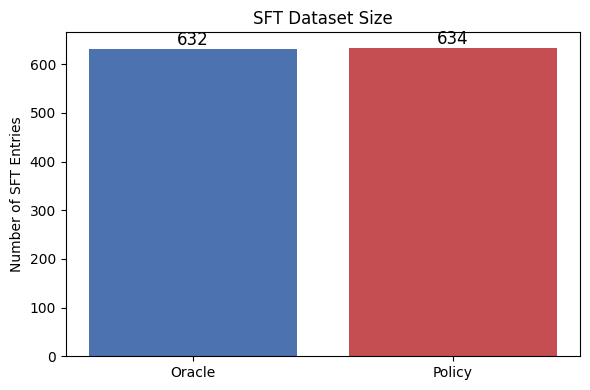

In [24]:
print(f"Oracle SFT entries: {len(oracle_sft)}")
print(f"Policy SFT entries: {len(policy_sft)}")

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["Oracle", "Policy"], [len(oracle_sft), len(policy_sft)], color=["#4C72B0", "#C44E52"])
ax.bar_label(bars, fontsize=12)
ax.set_ylabel("Number of SFT Entries")
ax.set_title("SFT Dataset Size")
plt.tight_layout()
plt.show()

## 3. SFT Data Analysis Helpers

In [25]:
def analyze_sft_entry(messages):
    """Extract stats from a single SFT conversation."""
    total_msgs = len(messages)
    
    # Separate by role
    system_msgs = [m for m in messages if m["role"] == "system"]
    user_msgs = [m for m in messages if m["role"] == "user"]
    asst_msgs = [m for m in messages if m["role"] == "assistant"]
    
    # Number of turns (assistant messages = action steps)
    num_turns = len(asst_msgs)
    
    # Extract function/tool calls from assistant messages
    action_types = Counter()
    action_sequence = []
    for m in asst_msgs:
        content = m["content"]
        func_matches = re.findall(r'<function=(\w+)>', content)
        if func_matches:
            for fn in func_matches:
                action_types[fn] += 1
                action_sequence.append(fn)
        elif '<execute_bash>' in content:
            action_types['execute_bash'] += 1
            action_sequence.append('execute_bash')
        elif '<execute_ipython>' in content:
            action_types['execute_ipython'] += 1
            action_sequence.append('execute_ipython')
        else:
            action_types['text_only'] += 1
            action_sequence.append('text_only')
    
    # Content length stats
    total_content_len = sum(len(m["content"]) for m in messages)
    system_len = sum(len(m["content"]) for m in system_msgs)
    user_content_len = sum(len(m["content"]) for m in user_msgs)
    asst_content_len = sum(len(m["content"]) for m in asst_msgs)
    
    # Mean assistant message length
    asst_lens = [len(m["content"]) for m in asst_msgs]
    mean_asst_len = np.mean(asst_lens) if asst_lens else 0
    
    # Mean user (observation) message length (excluding first user msg which is the task)
    obs_msgs = user_msgs[1:]  # skip the task description
    obs_lens = [len(m["content"]) for m in obs_msgs]
    mean_obs_len = np.mean(obs_lens) if obs_lens else 0
    
    # Check for error observations in user messages
    error_obs_count = 0
    for m in user_msgs:
        content = m["content"]
        if 'EXECUTION RESULT of' in content:
            if 'Error' in content or 'ERROR' in content or 'Traceback' in content:
                error_obs_count += 1
    
    total_obs = len(obs_msgs)
    error_rate = error_obs_count / total_obs if total_obs > 0 else 0
    
    # Detect stuck loops: 5+ consecutive identical function calls
    stuck_in_loop = False
    max_repeat = 0
    if len(action_sequence) >= 5:
        for i in range(len(action_sequence) - 4):
            window = action_sequence[i:i+5]
            if all(a == window[0] for a in window):
                streak = 0
                for a in action_sequence[i:]:
                    if a == window[0]:
                        streak += 1
                    else:
                        break
                max_repeat = max(max_repeat, streak)
                if streak >= 5:
                    stuck_in_loop = True
    
    # Check if conversation ends with finish action
    has_finish = 'finish' in action_types
    
    return {
        "total_msgs": total_msgs,
        "num_turns": num_turns,
        "action_types": dict(action_types),
        "action_sequence": action_sequence,
        "total_content_len": total_content_len,
        "system_len": system_len,
        "user_content_len": user_content_len,
        "asst_content_len": asst_content_len,
        "mean_asst_len": mean_asst_len,
        "mean_obs_len": mean_obs_len,
        "error_obs_count": error_obs_count,
        "total_obs": total_obs,
        "error_rate": error_rate,
        "stuck_in_loop": stuck_in_loop,
        "max_repeat": max_repeat,
        "has_finish": has_finish,
    }

def analyze_all_sft(sft_data):
    return [analyze_sft_entry(msgs) for msgs in sft_data]

print("Analyzing oracle SFT data...")
oracle_stats = analyze_all_sft(oracle_sft)
print("Analyzing policy SFT data...")
policy_stats = analyze_all_sft(policy_sft)
print("Done.")

Analyzing oracle SFT data...


Analyzing policy SFT data...
Done.


## 4. Conversation Length Statistics

In [26]:
oracle_turns = [s["num_turns"] for s in oracle_stats]
policy_turns = [s["num_turns"] for s in policy_stats]

def print_dist_stats(name, values):
    arr = np.array(values)
    print(f"{name}:")
    print(f"  Mean: {arr.mean():.1f}, Median: {np.median(arr):.1f}, "
          f"Std: {arr.std():.1f}, Min: {arr.min()}, Max: {arr.max()}")

print("\n--- Number of Turns (assistant messages) ---")
print_dist_stats("Oracle", oracle_turns)
print_dist_stats("Policy", policy_turns)

oracle_total_msgs = [s["total_msgs"] for s in oracle_stats]
policy_total_msgs = [s["total_msgs"] for s in policy_stats]

print("\n--- Total Messages ---")
print_dist_stats("Oracle", oracle_total_msgs)
print_dist_stats("Policy", policy_total_msgs)


--- Number of Turns (assistant messages) ---
Oracle:
  Mean: 57.6, Median: 55.0, Std: 21.9, Min: 18, Max: 143
Policy:
  Mean: 64.2, Median: 60.0, Std: 17.4, Min: 30, Max: 100

--- Total Messages ---
Oracle:
  Mean: 116.1, Median: 111.0, Std: 43.7, Min: 37, Max: 287
Policy:
  Mean: 129.5, Median: 121.0, Std: 34.9, Min: 61, Max: 201


/tmp/ipykernel_3888307/2607550721.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([oracle_turns, policy_turns], labels=["Oracle", "Policy"], patch_artist=True)


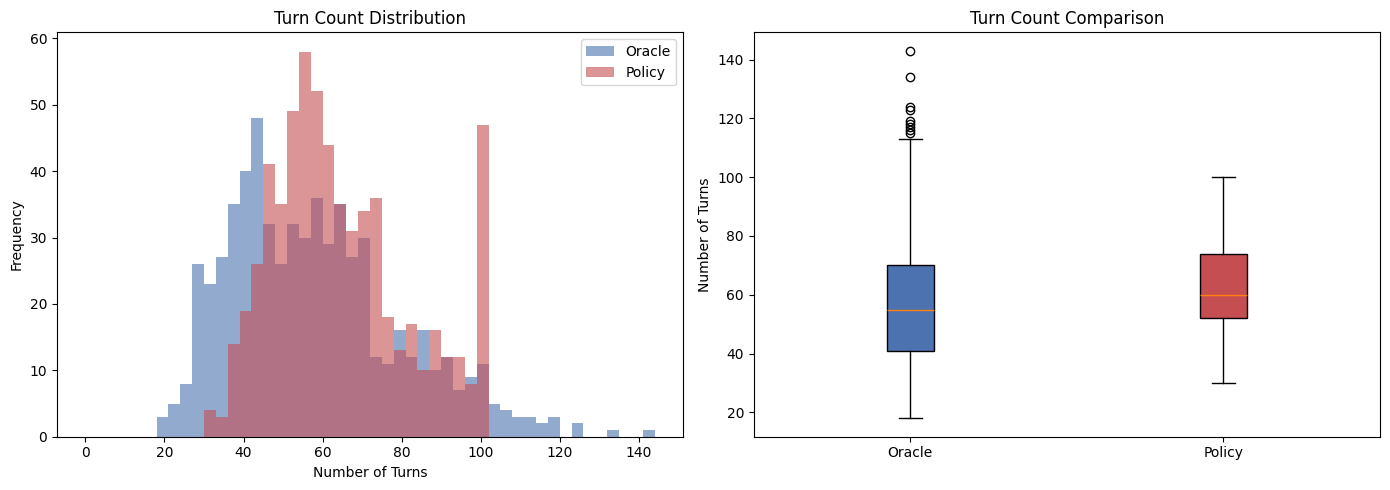

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax = axes[0]
bins = np.arange(0, max(max(oracle_turns), max(policy_turns)) + 3, 3)
ax.hist(oracle_turns, bins=bins, alpha=0.6, label="Oracle", color="#4C72B0")
ax.hist(policy_turns, bins=bins, alpha=0.6, label="Policy", color="#C44E52")
ax.set_xlabel("Number of Turns")
ax.set_ylabel("Frequency")
ax.set_title("Turn Count Distribution")
ax.legend()

# Box plot
ax = axes[1]
bp = ax.boxplot([oracle_turns, policy_turns], labels=["Oracle", "Policy"], patch_artist=True)
bp["boxes"][0].set_facecolor("#4C72B0")
bp["boxes"][1].set_facecolor("#C44E52")
ax.set_ylabel("Number of Turns")
ax.set_title("Turn Count Comparison")

plt.tight_layout()
plt.show()

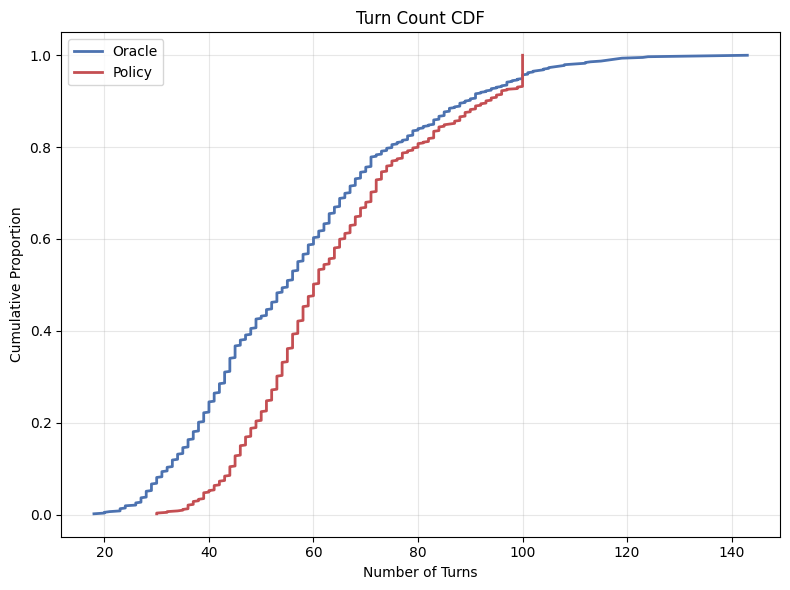

In [28]:
# CDF comparison of turn counts
fig, ax = plt.subplots(figsize=(8, 6))
for data, label, color in [(oracle_turns, "Oracle", "#4C72B0"), (policy_turns, "Policy", "#C44E52")]:
    sorted_data = np.sort(data)
    cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    ax.plot(sorted_data, cdf, label=label, color=color, linewidth=2)
ax.set_xlabel("Number of Turns")
ax.set_ylabel("Cumulative Proportion")
ax.set_title("Turn Count CDF")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Content Length Statistics

In [29]:
oracle_total_len = [s["total_content_len"] for s in oracle_stats]
policy_total_len = [s["total_content_len"] for s in policy_stats]

oracle_asst_len = [s["asst_content_len"] for s in oracle_stats]
policy_asst_len = [s["asst_content_len"] for s in policy_stats]

oracle_user_len = [s["user_content_len"] for s in oracle_stats]
policy_user_len = [s["user_content_len"] for s in policy_stats]

print("--- Total Content Length (chars) ---")
print_dist_stats("Oracle", oracle_total_len)
print_dist_stats("Policy", policy_total_len)

print("\n--- Assistant Content Length (chars) ---")
print_dist_stats("Oracle", oracle_asst_len)
print_dist_stats("Policy", policy_asst_len)

print("\n--- User/Observation Content Length (chars) ---")
print_dist_stats("Oracle", oracle_user_len)
print_dist_stats("Policy", policy_user_len)

--- Total Content Length (chars) ---
Oracle:
  Mean: 171853.7, Median: 163696.0, Std: 54114.8, Min: 64150, Max: 379595
Policy:
  Mean: 234636.2, Median: 226349.5, Std: 55859.9, Min: 110476, Max: 508032

--- Assistant Content Length (chars) ---
Oracle:
  Mean: 36503.0, Median: 34606.0, Std: 16329.7, Min: 9187, Max: 98130
Policy:
  Mean: 53051.4, Median: 49069.0, Std: 17205.3, Min: 18956, Max: 131639

--- User/Observation Content Length (chars) ---
Oracle:
  Mean: 107450.7, Median: 98663.0, Std: 41778.0, Min: 24604, Max: 267347
Policy:
  Mean: 153684.7, Median: 148058.5, Std: 45896.5, Min: 49680, Max: 391302


/tmp/ipykernel_3888307/174642675.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([o_data, p_data], labels=["Oracle", "Policy"], patch_artist=True)
/tmp/ipykernel_3888307/174642675.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([o_data, p_data], labels=["Oracle", "Policy"], patch_artist=True)
/tmp/ipykernel_3888307/174642675.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([o_data, p_data], labels=["Oracle", "Policy"], patch_artist=True)


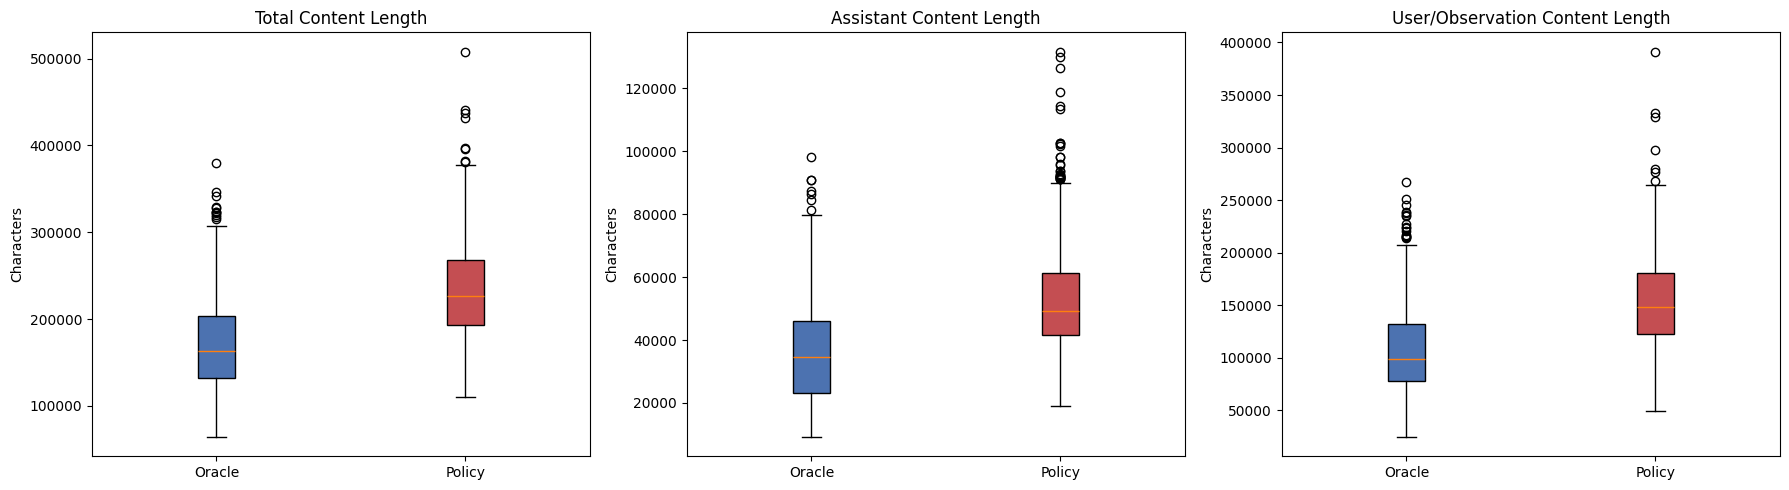

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, o_data, p_data, title in zip(
    axes,
    [oracle_total_len, oracle_asst_len, oracle_user_len],
    [policy_total_len, policy_asst_len, policy_user_len],
    ["Total Content Length", "Assistant Content Length", "User/Observation Content Length"]
):
    bp = ax.boxplot([o_data, p_data], labels=["Oracle", "Policy"], patch_artist=True)
    bp["boxes"][0].set_facecolor("#4C72B0")
    bp["boxes"][1].set_facecolor("#C44E52")
    ax.set_ylabel("Characters")
    ax.set_title(title)

plt.tight_layout()
plt.show()

/tmp/ipykernel_3888307/2019056078.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([oracle_mean_asst, policy_mean_asst], labels=["Oracle", "Policy"], patch_artist=True)
/tmp/ipykernel_3888307/2019056078.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([oracle_mean_obs, policy_mean_obs], labels=["Oracle", "Policy"], patch_artist=True)


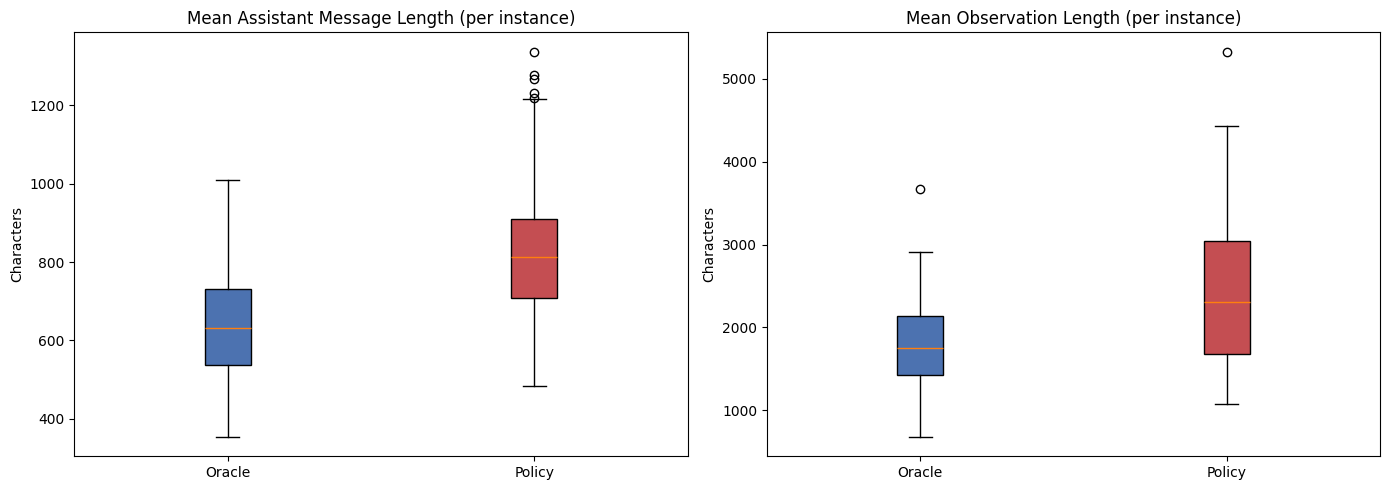

In [ ]:
# Mean assistant message length per instance
oracle_mean_asst = [s["mean_asst_len"] for s in oracle_stats]
policy_mean_asst = [s["mean_asst_len"] for s in policy_stats]

oracle_mean_obs = [s["mean_obs_len"] for s in oracle_stats]
policy_mean_obs = [s["mean_obs_len"] for s in policy_stats]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bp = ax.boxplot([oracle_mean_asst, policy_mean_asst], labels=["Oracle", "Policy"], patch_artist=True)
bp["boxes"][0].set_facecolor("#4C72B0")
bp["boxes"][1].set_facecolor("#C44E52")
ax.set_ylabel("Characters")
ax.set_title("Mean Assistant Message Length (per instance)")

ax = axes[1]
bp = ax.boxplot([oracle_mean_obs, policy_mean_obs], labels=["Oracle", "Policy"], patch_artist=True)
bp["boxes"][0].set_facecolor("#4C72B0")
bp["boxes"][1].set_facecolor("#C44E52")
ax.set_ylabel("Characters")
ax.set_title("Mean Observation Length (per instance)")

plt.tight_layout()
plt.show()

## 6. Tool Use Types

In [ ]:
def aggregate_action_types(stats):
    total = Counter()
    for s in stats:
        total.update(s["action_types"])
    return total

oracle_actions = aggregate_action_types(oracle_stats)
policy_actions = aggregate_action_types(policy_stats)

all_types = sorted(set(oracle_actions.keys()) | set(policy_actions.keys()))

oracle_total_actions = sum(oracle_actions.values())
policy_total_actions = sum(policy_actions.values())

print(f"{'Action Type':<25} {'Oracle':>10} {'Policy':>10} {'Oracle %':>10} {'Policy %':>10}")
print("-" * 67)
for t in all_types:
    oc = oracle_actions.get(t, 0)
    pc = policy_actions.get(t, 0)
    print(f"{t:<25} {oc:>10} {pc:>10} {100*oc/oracle_total_actions:>9.1f}% {100*pc/policy_total_actions:>9.1f}%")
print("-" * 67)
print(f"{'TOTAL':<25} {oracle_total_actions:>10} {policy_total_actions:>10}")

Action Type                   Oracle     Policy   Oracle %   Policy %
-------------------------------------------------------------------
execute_bash                    2741       4141      48.0%      52.4%
finish                            99        109       1.7%       1.4%
str_replace_editor              2554       3264      44.7%      41.3%
task_tracker                      32         81       0.6%       1.0%
text_only                          1          1       0.0%       0.0%
think                            288        309       5.0%       3.9%
-------------------------------------------------------------------
TOTAL                           5715       7905


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grouped bar chart: counts
ax = axes[0]
x = np.arange(len(all_types))
width = 0.35
o_vals = [oracle_actions.get(t, 0) for t in all_types]
p_vals = [policy_actions.get(t, 0) for t in all_types]
ax.bar(x - width/2, o_vals, width, label="Oracle", color="#4C72B0")
ax.bar(x + width/2, p_vals, width, label="Policy", color="#C44E52")
ax.set_xticks(x)
ax.set_xticklabels(all_types, rotation=45, ha="right")
ax.set_ylabel("Count")
ax.set_title("Action Type Counts")
ax.legend()

# Normalized bar chart: proportions
ax = axes[1]
o_pct = [100 * oracle_actions.get(t, 0) / oracle_total_actions for t in all_types]
p_pct = [100 * policy_actions.get(t, 0) / policy_total_actions for t in all_types]
ax.bar(x - width/2, o_pct, width, label="Oracle", color="#4C72B0")
ax.bar(x + width/2, p_pct, width, label="Policy", color="#C44E52")
ax.set_xticks(x)
ax.set_xticklabels(all_types, rotation=45, ha="right")
ax.set_ylabel("Percentage (%)")
ax.set_title("Action Type Distribution (%)")
ax.legend()

plt.tight_layout()
plt.show()

## 7. Error Observation Analysis (Tool Misuse)

In [ ]:
def error_summary(stats, label):
    error_rates = [s["error_rate"] for s in stats]
    error_counts = [s["error_obs_count"] for s in stats]
    total_obs = [s["total_obs"] for s in stats]
    total_errors = sum(error_counts)
    total_ob = sum(total_obs)
    print(f"{label}:")
    print(f"  Total observations:      {total_ob}")
    print(f"  Total error observations: {total_errors}")
    print(f"  Overall error rate:       {100*total_errors/total_ob:.1f}%" if total_ob > 0 else "  N/A")
    arr = np.array(error_rates)
    print(f"  Per-instance error rate:  mean={100*arr.mean():.1f}%, "
          f"median={100*np.median(arr):.1f}%, max={100*arr.max():.1f}%")
    with_errors = sum(1 for r in error_rates if r > 0)
    print(f"  Instances with any error: {with_errors}/{len(error_rates)} "
          f"({100*with_errors/len(error_rates):.1f}%)")

error_summary(oracle_stats, "Oracle")
print()
error_summary(policy_stats, "Policy")

Oracle:
  Total observations:      5616
  Total error observations: 878
  Overall error rate:       15.6%
  Per-instance error rate:  mean=15.6%, median=13.7%, max=45.5%
  Instances with any error: 95/96 (99.0%)

Policy:
  Total observations:      7783
  Total error observations: 1368
  Overall error rate:       17.6%
  Per-instance error rate:  mean=17.7%, median=15.6%, max=53.7%
  Instances with any error: 121/122 (99.2%)


/tmp/ipykernel_3888307/2318033428.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([oracle_error_rates, policy_error_rates], labels=["Oracle", "Policy"], patch_artist=True)


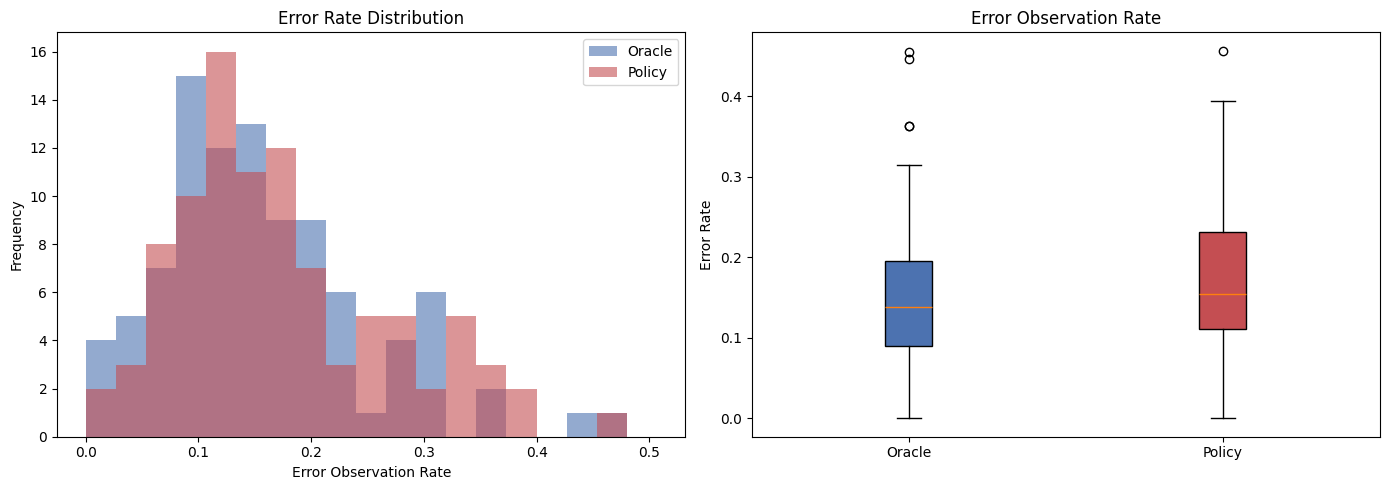

In [ ]:
oracle_error_rates = [s["error_rate"] for s in oracle_stats]
policy_error_rates = [s["error_rate"] for s in policy_stats]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bins = np.linspace(0, max(max(oracle_error_rates), max(policy_error_rates)) + 0.05, 20)
ax.hist(oracle_error_rates, bins=bins, alpha=0.6, label="Oracle", color="#4C72B0")
ax.hist(policy_error_rates, bins=bins, alpha=0.6, label="Policy", color="#C44E52")
ax.set_xlabel("Error Observation Rate")
ax.set_ylabel("Frequency")
ax.set_title("Error Rate Distribution")
ax.legend()

ax = axes[1]
bp = ax.boxplot([oracle_error_rates, policy_error_rates], labels=["Oracle", "Policy"], patch_artist=True)
bp["boxes"][0].set_facecolor("#4C72B0")
bp["boxes"][1].set_facecolor("#C44E52")
ax.set_ylabel("Error Rate")
ax.set_title("Error Observation Rate")

plt.tight_layout()
plt.show()

## 8. Stuck in Loop Analysis

In [ ]:
oracle_stuck = sum(1 for s in oracle_stats if s["stuck_in_loop"])
policy_stuck = sum(1 for s in policy_stats if s["stuck_in_loop"])

oracle_n = len(oracle_stats)
policy_n = len(policy_stats)

print(f"Oracle: {oracle_stuck}/{oracle_n} stuck in loop ({100*oracle_stuck/oracle_n:.1f}%)")
print(f"Policy: {policy_stuck}/{policy_n} stuck in loop ({100*policy_stuck/policy_n:.1f}%)")

# Max repeat streaks
oracle_repeats = [s["max_repeat"] for s in oracle_stats if s["max_repeat"] > 0]
policy_repeats = [s["max_repeat"] for s in policy_stats if s["max_repeat"] > 0]

if oracle_repeats:
    print(f"\nOracle repeat streaks (among those with repeats): mean={np.mean(oracle_repeats):.1f}, max={max(oracle_repeats)}")
if policy_repeats:
    print(f"Policy repeat streaks (among those with repeats): mean={np.mean(policy_repeats):.1f}, max={max(policy_repeats)}")

Oracle: 86/96 stuck in loop (89.6%)
Policy: 112/122 stuck in loop (91.8%)

Oracle repeat streaks (among those with repeats): mean=8.3, max=27
Policy repeat streaks (among those with repeats): mean=7.8, max=24


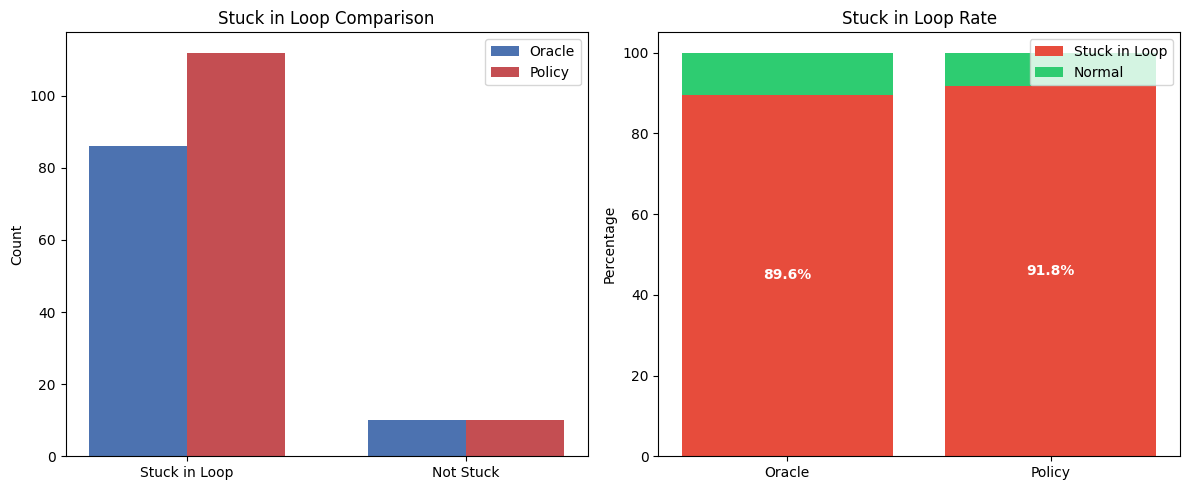

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart: stuck vs not stuck
ax = axes[0]
x = np.arange(2)
width = 0.35
ax.bar(x - width/2, [oracle_stuck, oracle_n - oracle_stuck], width,
       label="Oracle", color="#4C72B0")
ax.bar(x + width/2, [policy_stuck, policy_n - policy_stuck], width,
       label="Policy", color="#C44E52")
ax.set_xticks(x)
ax.set_xticklabels(["Stuck in Loop", "Not Stuck"])
ax.set_ylabel("Count")
ax.set_title("Stuck in Loop Comparison")
ax.legend()

# Stacked bar: stuck rate as percentage
ax = axes[1]
runs = ["Oracle", "Policy"]
stuck_pct = [100*oracle_stuck/oracle_n, 100*policy_stuck/policy_n]
not_stuck_pct = [100 - s for s in stuck_pct]
ax.bar(runs, stuck_pct, label="Stuck in Loop", color="#E74C3C")
ax.bar(runs, not_stuck_pct, bottom=stuck_pct, label="Normal", color="#2ECC71")
for i, (s, ns) in enumerate(zip(stuck_pct, not_stuck_pct)):
    ax.text(i, s/2, f"{s:.1f}%", ha="center", va="center", fontweight="bold", color="white")
ax.set_ylabel("Percentage")
ax.set_title("Stuck in Loop Rate")
ax.legend()

plt.tight_layout()
plt.show()

## 9. Finish Action Analysis

In [ ]:
oracle_finish = sum(1 for s in oracle_stats if s["has_finish"])
policy_finish = sum(1 for s in policy_stats if s["has_finish"])

print(f"Oracle: {oracle_finish}/{oracle_n} end with finish ({100*oracle_finish/oracle_n:.1f}%)")
print(f"Policy: {policy_finish}/{policy_n} end with finish ({100*policy_finish/policy_n:.1f}%)")

fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(2)
width = 0.35
ax.bar(x - width/2, [oracle_finish, oracle_n - oracle_finish], width,
       label="Oracle", color="#4C72B0")
ax.bar(x + width/2, [policy_finish, policy_n - policy_finish], width,
       label="Policy", color="#C44E52")
ax.set_xticks(x)
ax.set_xticklabels(["Has Finish", "No Finish"])
ax.set_ylabel("Count")
ax.set_title("Finish Action Presence")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Summary Table

In [ ]:
def compute_sft_summary(stats, label):
    turns = [s["num_turns"] for s in stats]
    total_lens = [s["total_content_len"] for s in stats]
    asst_lens = [s["asst_content_len"] for s in stats]
    error_rates = [s["error_rate"] for s in stats]
    stuck = sum(1 for s in stats if s["stuck_in_loop"])
    finish = sum(1 for s in stats if s["has_finish"])
    n = len(stats)
    return {
        "Run": label,
        "Instances": n,
        "Mean Turns": f"{np.mean(turns):.1f}",
        "Median Turns": f"{np.median(turns):.0f}",
        "Mean Total Len": f"{np.mean(total_lens):.0f}",
        "Mean Asst Len": f"{np.mean(asst_lens):.0f}",
        "Mean Error %": f"{100*np.mean(error_rates):.1f}%",
        "Stuck Loop %": f"{100*stuck/n:.1f}%",
        "Has Finish %": f"{100*finish/n:.1f}%",
    }

rows = [
    compute_sft_summary(oracle_stats, "Oracle"),
    compute_sft_summary(policy_stats, "Policy"),
]

keys = list(rows[0].keys())
col_widths = [max(len(str(r[k])) for r in rows + [{k: k for k in keys}]) for k in keys]
header = " | ".join(k.ljust(w) for k, w in zip(keys, col_widths))
print(header)
print("-" * len(header))
for r in rows:
    print(" | ".join(str(r[k]).ljust(w) for k, w in zip(keys, col_widths)))

## 11. Distribution Comparison

In [ ]:
# Turn count distribution comparison: sorted profiles
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sorted turn counts
ax = axes[0]
ax.plot(range(len(oracle_stats)), sorted([s["num_turns"] for s in oracle_stats], reverse=True),
        label=f"Oracle (n={len(oracle_stats)})", color="#4C72B0", linewidth=1.5)
ax.plot(range(len(policy_stats)), sorted([s["num_turns"] for s in policy_stats], reverse=True),
        label=f"Policy (n={len(policy_stats)})", color="#C44E52", linewidth=1.5)
ax.set_xlabel("Entry Index (sorted)")
ax.set_ylabel("Number of Turns")
ax.set_title("Sorted Turn Count Profile")
ax.legend()


# Sorted total content lengthplt.show()

ax = axes[1]plt.tight_layout()

ax.plot(range(len(oracle_stats)), sorted([s["total_content_len"] for s in oracle_stats], reverse=True),

        label=f"Oracle (n={len(oracle_stats)})", color="#4C72B0", linewidth=1.5)ax.legend()

ax.plot(range(len(policy_stats)), sorted([s["total_content_len"] for s in policy_stats], reverse=True),ax.set_title("Sorted Content Length Profile")

        label=f"Policy (n={len(policy_stats)})", color="#C44E52", linewidth=1.5)ax.set_ylabel("Total Content Length (chars)")
ax.set_xlabel("Entry Index (sorted)")

In [ ]:
# Percentile comparison table
percentiles = [10, 25, 50, 75, 90, 95, 99]
metrics = [
    ("Turns", [s["num_turns"] for s in oracle_stats], [s["num_turns"] for s in policy_stats]),
    ("Total Len", [s["total_content_len"] for s in oracle_stats], [s["total_content_len"] for s in policy_stats]),
    ("Asst Len", [s["asst_content_len"] for s in oracle_stats], [s["asst_content_len"] for s in policy_stats]),
    ("Error Rate", [s["error_rate"] for s in oracle_stats], [s["error_rate"] for s in policy_stats]),
]

for metric_name, o_vals, p_vals in metrics:
    print(f"\n--- {metric_name} Percentiles ---")
    header = f"{'Percentile':<12}" + "".join(f"{'P'+str(p):>10}" for p in percentiles)
    print(header)
    o_pcts = np.percentile(o_vals, percentiles)

    p_pcts = np.percentile(p_vals, percentiles)    print(f"{'Policy':<12}" + "".join(f"{v:>10.1f}" for v in p_pcts))
    print(f"{'Oracle':<12}" + "".join(f"{v:>10.1f}" for v in o_pcts))

In [ ]:
# Action type diversity comparison
oracle_diversity = [len(s["action_types"]) for s in oracle_stats]
policy_diversity = [len(s["action_types"]) for s in policy_stats]

print("--- Action Type Diversity (unique action types per instance) ---")
print_dist_stats("Oracle", oracle_diversity)
print_dist_stats("Policy", policy_diversity)

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot([oracle_diversity, policy_diversity], labels=["Oracle", "Policy"], patch_artist=True)
bp["boxes"][0].set_facecolor("#4C72B0")
bp["boxes"][1].set_facecolor("#C44E52")
ax.set_ylabel("Unique Action Types")
ax.set_title("Action Type Diversity per Instance")
plt.tight_layout()
plt.show()